# Deep Q-Learning for Cliff-walking game

This notebook aims at training, validating and testing a reinforncement learning agent using Deep Q-Learning. The notebook includes:

1. The following questions involve writing code to complete specific tasks.  
2. Initiate a Frozen lake environment and an agent. Train the agent using <b>Deep Q-Learning</b>.
3. Print out the optimal policy, i.e., what is the best action to take at each stage.  
4. Test the optimal policy given by the Deep Q-Learning.  

Cliff walking involves crossing a gridworld from start to goal while avoiding falling off a cliff. Each time step incurs -1 reward, unless the player stepped into the cliff, which incurs -100 reward.

![Cliff walking](https://gymnasium.farama.org/_images/cliff_walking.gif)

More details can be found at https://gymnasium.farama.org/environments/toy_text/cliff_walking/

### Install libraries and initiate a frozen lake map

In [ ]:
# Install gymnasium game environment
!pip install gymnasium
!pip install gymnasium[toy-text]

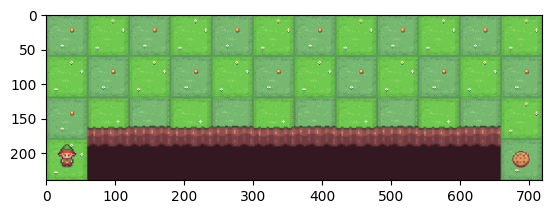

In [ ]:
### Please do not change this code

# Load libraries
import gymnasium as gym
import matplotlib.pyplot as plt

# Initialize the environment\
env = gym.make('CliffWalking-v0', render_mode='rgb_array')
state_size = env.observation_space.n    # Number of states
action_size = env.action_space.n    # Number of actions of this game: four, 0: left, 1:down, 2: right, 3: up.
env.reset()    # Reset environment, i.e., set agent position to state 0
plt.imshow(env.render())    # Visualize environment map

In [ ]:
import numpy as np
import random
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import imageio

## Define Agent

In [ ]:
# Define agent attibutes and methods
class Agent:
    def __init__(self, state_size, action_size):
        self.memory = deque(maxlen=2048)   # Deque is quick for append and pop operations from both the ends of the container.
        self.batch_size = 256    # Batch size of data samples for training policy (and target) network. In this example, the two networks are identical.
        self.learning_rate = 0.001    # Learning rate of
        self.epsilon = 1    # Start (max) value of epsilon
        self.min_eps = 0.01    # End (min) value of epsilon
        self.eps_decay = 0.001     # Decay factor for decreasing epsilon over episodes
        self.gamma = 0.96    # Discount factor
        self.state_size = state_size    # Number of states
        self.action_size =  action_size    # Number of possible actions the agent can take: four, 0: left, 1:down, 2: right, 3: up.
        self.episode = 0     # Agent current episode
        # self.epsilon_lst = []    # Track epsilon values over episodes
        self.max_steps = 150    # Maximum number of steps the agent can carry out in an episode
        self.train_episodes = 1000    # Number of training episodes
        # Create policy network and target network
        self.model = self.build_model()
        self.target_model = self.build_model()
        self.update_target_model()  # Initialize target model

    # Build model architecture and compile it
    def build_model(self):
        model = Sequential()    # Initiate a simple sequential model
        model.add(Dense(48, input_dim=self.state_size, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    # Add an eposide to agent's memory
    def add_memory(self, state, action, reward, new_state, terminated):
        self.memory.append((state, action, reward, new_state, terminated))    # Insert the value in its argument to the right end of the deque

    # Get action when agent is at a certain state
    def action(self, state):
        if np.random.rand() > self.epsilon:     # Epsilon starts at 1. rand > epsilon: exploit, rand <= epsilon: explore.
            return np.argmax(self.model.predict(state, verbose=0))     # Take greedy action. Verbose=0 mutes output prediction log.
        return env.action_space.sample()

    def update_target_model(self):
        """Copy weights from the policy model to the target model"""
        self.target_model.set_weights(self.model.get_weights())

    def replay(self):
        minibatch = random.sample(self.memory, self.batch_size)
        minibatch_state = np.concatenate(np.array(minibatch, dtype=object)[:, 0], axis=0)
        minibatch_action = np.array(minibatch, dtype=object)[:, 1]
        minibatch_reward = np.array(minibatch, dtype=object)[:, 2]
        minibatch_new_state = np.concatenate(np.array(minibatch, dtype=object)[:, 3], axis=0)
        minibatch_terminated = np.array(minibatch, dtype=object)[:, 4]

        q_state = self.model.predict(minibatch_state, verbose=0)
        q_new_state = self.model.predict(minibatch_new_state, verbose=0)  # Use the policy network to estimate target Q-values

        q_action_optimal = np.add(minibatch_reward, self.gamma * np.amax(q_new_state, axis=1))
        for i in range(0, self.batch_size):
            q_state[i][minibatch_action[i]] = q_action_optimal[i]

        self.model.fit(minibatch_state, q_state, epochs=1, verbose=0)

    def save_model(self, name):
        self.model.save_weights(name)

    def load_model(self, name):
        self.model.load_weights(name)

# Initialize a reinforcement learning agent
agent = Agent(state_size, action_size)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
reward_episodes = []    # Track rewards over episodes
step_episodes = []    # Track number of steps (in each episode until termination) over episodes
epsilon_episodes = []    # Track epsilon values over episodes

for episode in range(agent.train_episodes):
    agent.episode = episode    # Set agent's current episode
    state = env.reset()    # Reset environment, i.e., agent position is set to state 0
    state_arr = np.zeros(agent.state_size)    # Initialze current state array, e.g., [0. 0. 0. 0. 0. 0. 0. 0. 0.]
    state_arr[state[0]] = 1    # Set the agent position in the current state array, i.e., [[1. 0. 0. 0. 0. 0. 0. 0. 0.]]
    state_arr = np.reshape(state_arr, [1, agent.state_size])    # Reshape array
    reward = 0    # Initialize reward to zero
    terminated = False    # Initialize terminated to False

    img_lst = [env.render()]    # Initialize list to store visualization frames
    total_reward = 0
    for step in range(agent.max_steps):
        action = agent.action(state_arr)    # Take action at the current state. This ccan be exploitation or exploration, depending on agent.epsilon
        new_state, reward, terminated, info, _ = env.step(action)     # Terminated: whether a terminal state is reached after taking the action. Ref: https://www.gymlibrary.dev/api/core/#gym.Env.step

        total_reward += reward
        new_state_arr = np.zeros(agent.state_size)    # Initialze new state array, e.g., [[0. 0. 0. 0. 0. 0. 0. 0. 0.]]
        new_state_arr[new_state] = 1    # Set the agent position in the new state array, after taking the action, e.g., [[0. 1. 0. 0. 0. 0. 0. 0. 0.]]
        new_state_arr = np.reshape(new_state_arr, [1, agent.state_size])    # Reshape array
        agent.add_memory(state_arr, action, reward, new_state_arr, terminated)    # Add current step to agent's memory
        state_arr = new_state_arr    # New state becomes state

        # Render map imgage for visualization every K episodes
        if agent.episode % 50 == 0:
            animation_file = "training_episode_" + str(agent.episode) + "_steps_" + str(step) + ".gif"
            img = env.render()    # Render current environment image
            img_lst.append(img)    # Append environment images to make animation

        if terminated:
            break

        if reward == -100:
            break

    print("Episode: " + str(agent.episode) + ", Steps: " + str(step) + ", epsilon: " + str(round(agent.epsilon,2)) + ", Reward: " + str(total_reward))
    reward_episodes.append(reward)    # Add reward to list for tracking purpose
    step_episodes.append(step)    # Add step to list for tracking purpose
    epsilon_episodes.append(agent.epsilon)    # Add epsilon to list for tracking purpose

    ### Update epsilon value which is the ratio of exploitation and exploration
    if agent.epsilon < agent.min_eps:
        agent.epsilon = agent.min_eps    # Set the minimum value of epsilon so that there is always a chance for exploration.
    else:
        agent.epsilon = np.exp(-agent.eps_decay*agent.episode)    # Decrease exploration / Increase exploitation overtime as the agent knows more about the environment

    ### If enough experiences collected in the memory, use them for training
    if len(agent.memory) > agent.batch_size:
        agent.replay()

    if len(img_lst)>1:
      animation_file = f"training_episode_{agent.episode}_steps_{step}.gif"
      imageio.mimsave(animation_file, img_lst, format='GIF', duration=0.5)
    # Update the target network weight
    if episode % 10 == 0:
      agent.update_target_model()

print('Average success rate of training episodes: ', round(np.mean(reward_episodes),2))

Episode: 0, Steps: 1, epsilon: 1, Reward: -101
Episode: 1, Steps: 14, epsilon: 1.0, Reward: -114
Episode: 2, Steps: 7, epsilon: 1.0, Reward: -107
Episode: 3, Steps: 10, epsilon: 1.0, Reward: -110
Episode: 4, Steps: 4, epsilon: 1.0, Reward: -104
Episode: 5, Steps: 0, epsilon: 1.0, Reward: -100
Episode: 6, Steps: 23, epsilon: 1.0, Reward: -123
Episode: 7, Steps: 22, epsilon: 0.99, Reward: -122
Episode: 8, Steps: 1, epsilon: 0.99, Reward: -101
Episode: 9, Steps: 6, epsilon: 0.99, Reward: -106
Episode: 10, Steps: 0, epsilon: 0.99, Reward: -100
Episode: 11, Steps: 25, epsilon: 0.99, Reward: -125
Episode: 12, Steps: 0, epsilon: 0.99, Reward: -100
Episode: 13, Steps: 0, epsilon: 0.99, Reward: -100
Episode: 14, Steps: 2, epsilon: 0.99, Reward: -102
Episode: 15, Steps: 8, epsilon: 0.99, Reward: -108
Episode: 16, Steps: 6, epsilon: 0.99, Reward: -106
Episode: 17, Steps: 0, epsilon: 0.98, Reward: -100
Episode: 18, Steps: 0, epsilon: 0.98, Reward: -100
Episode: 19, Steps: 5, epsilon: 0.98, Reward:

### Plot cumulative average success rate over training episodes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

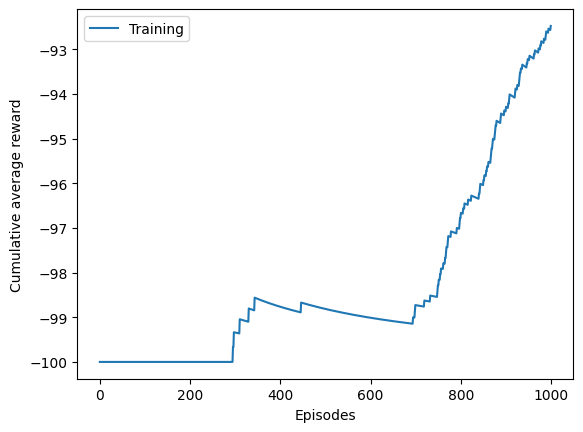

In [ ]:
df_reward_episodes = pd.DataFrame(reward_episodes)
cumulative_average_rewards = df_reward_episodes.expanding().mean()
plt.plot(cumulative_average_rewards)
plt.ylabel('Cumulative average reward')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper left')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Plot cumulative average steps of over training episodes

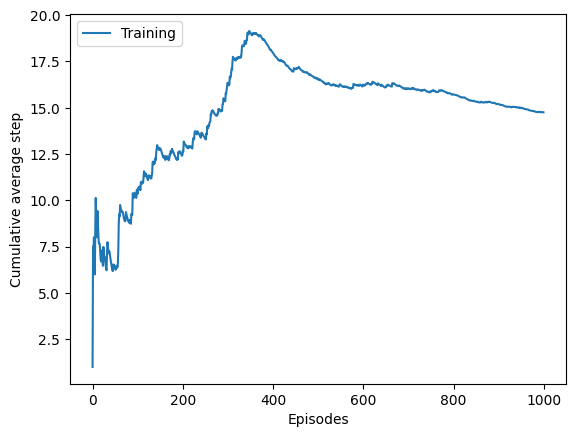

In [ ]:
df_step_episodes = pd.DataFrame(step_episodes)
cumulative_average_steps = df_step_episodes.expanding().mean()
plt.plot(cumulative_average_steps)
plt.ylabel('Cumulative average step')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper left')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Plot epsilon values over training episodes

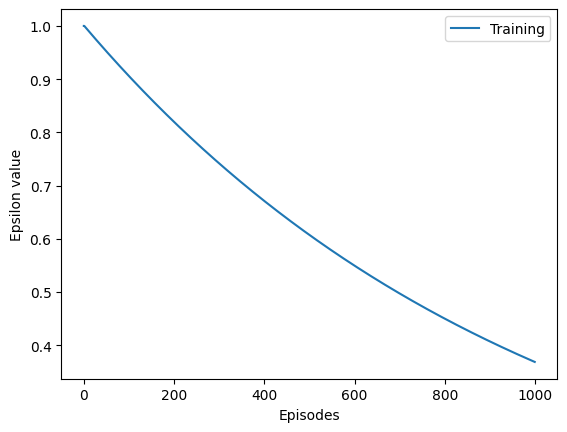

In [ ]:
# Plot epsilon values over episodes
plt.plot(epsilon_episodes)
plt.ylabel('Epsilon value')
plt.xlabel('Episodes')
plt.legend(['Training'], loc='upper right')
matplotlib.rcParams.update({'font.size': 10})
plt.show()

### Print optimal policy

In [ ]:
# Print the optimal policy, i.e., at each state what is the best action to take.
for state_index in range(agent.state_size):
    state_arr=np.zeros(agent.state_size)
    state_arr[state_index] = 1
    state_arr= np.reshape(state_arr, [1, agent.state_size])
    q_values = agent.model.predict(state_arr, verbose=0)
    best_action = np.argmax(q_values)
    print("State " + str(state_index) + ", Best action: " + str(best_action))

State 0, Best action: 1
State 1, Best action: 1
State 2, Best action: 1
State 3, Best action: 1
State 4, Best action: 1
State 5, Best action: 1
State 6, Best action: 1
State 7, Best action: 1
State 8, Best action: 2
State 9, Best action: 1
State 10, Best action: 2
State 11, Best action: 2
State 12, Best action: 1
State 13, Best action: 1
State 14, Best action: 2
State 15, Best action: 2
State 16, Best action: 1
State 17, Best action: 2
State 18, Best action: 1
State 19, Best action: 1
State 20, Best action: 1
State 21, Best action: 1
State 22, Best action: 2
State 23, Best action: 2
State 24, Best action: 1
State 25, Best action: 1
State 26, Best action: 1
State 27, Best action: 1
State 28, Best action: 1
State 29, Best action: 1
State 30, Best action: 1
State 31, Best action: 1
State 32, Best action: 1
State 33, Best action: 1
State 34, Best action: 1
State 35, Best action: 2
State 36, Best action: 0
State 37, Best action: 3
State 38, Best action: 3
State 39, Best action: 3
State 40, 

In [ ]:
# Test an episode
state = env.reset()    # Reset environment, i.e., agent position is set to state 0
state_arr = np.zeros(agent.state_size)    # Initialze current state array, e.g., [0. 0. 0. 0. 0. 0. 0. 0. 0.]
state_arr[state[0]] = 1    # Set the agent position in the current state array, i.e., [1. 0. 0. 0. 0. 0. 0. 0. 0.]
state_arr = np.reshape(state_arr, [1, agent.state_size])    # Reshape array, e.g., [[1. 0. 0. 0. 0. 0. 0. 0. 0.]]
terminated = False    # Initialize terminated to False
img_lst = [env.render()]    # Initialize list to store visualization frames
total_reward = 0
for step in range(agent.max_steps):
    q_values = agent.model.predict(state_arr, verbose=0)    # Get Q-values of all actions of the current state
    best_action = np.argmax(q_values)    # Get max-Q-value action, i.e., best action to take
    new_state, reward, terminated, info, _ = env.step(best_action)    # Perform the best action, get return from environment

    total_reward += reward
    new_state_arr = np.zeros(agent.state_size)    # Initialze new state array, e.g., [0. 0. 0. 0. 0. 0. 0. 0. 0.]
    new_state_arr[new_state] = 1    # Set the agent position in the new state array, after taking the action, e.g., [0. 1. 0. 0. 0. 0. 0. 0. 0.]
    new_state_arr = np.reshape(new_state_arr, [1, agent.state_size])    # Reshape array, e.g., [[0. 1. 0. 0. 0. 0. 0. 0. 0.]]
    print("Current state: " + str(np.argmax(state_arr)) + ", Action: " + str(best_action) + ", New state: " + str(np.argmax(new_state_arr)))
    state_arr = new_state_arr    # New state becomes state

    img = env.render()
    img_lst.append(img)

    if terminated:
        break
    if reward == -100:
        break

imageio.mimsave('test.gif', img_lst, format='GIF', duration=0.5)

Current state: 36, Action: 0, New state: 24
Current state: 24, Action: 1, New state: 25
Current state: 25, Action: 1, New state: 26
Current state: 26, Action: 1, New state: 27
Current state: 27, Action: 1, New state: 28
Current state: 28, Action: 1, New state: 29
Current state: 29, Action: 1, New state: 30
Current state: 30, Action: 1, New state: 31
Current state: 31, Action: 1, New state: 32
Current state: 32, Action: 1, New state: 33
Current state: 33, Action: 1, New state: 34
Current state: 34, Action: 1, New state: 35
Current state: 35, Action: 2, New state: 47


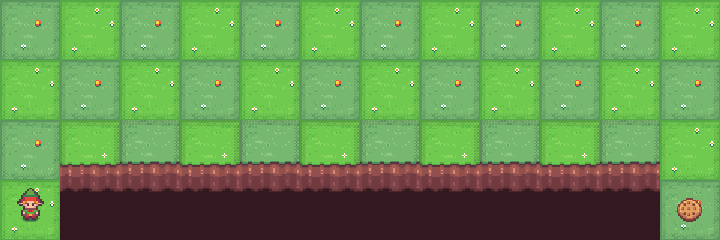

In [ ]:
# Display test result animation
from IPython.display import Image
Image('test.gif')